In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#convert excel file into dataframe which has rows and columns
data_frame = pd.read_excel("/kaggle/input/datasets/abhaykumar3650/telco-customer/Telco_customer_churn.xlsx")
data_frame

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [5]:
data_frame.shape #rows and columns are printed of the dataframe

(7043, 33)

In [6]:
#churn label yes or no but computer cant read string(semantically) so we must map this
#churn means customers leaving yes->leaving, no->not leaving
#do mapping(2 values)
#yes -> 1.....customer leaving
#no -> 0.....customer not leaving

In [7]:
data_frame.info() #object means string hai

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [8]:
data_frame['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

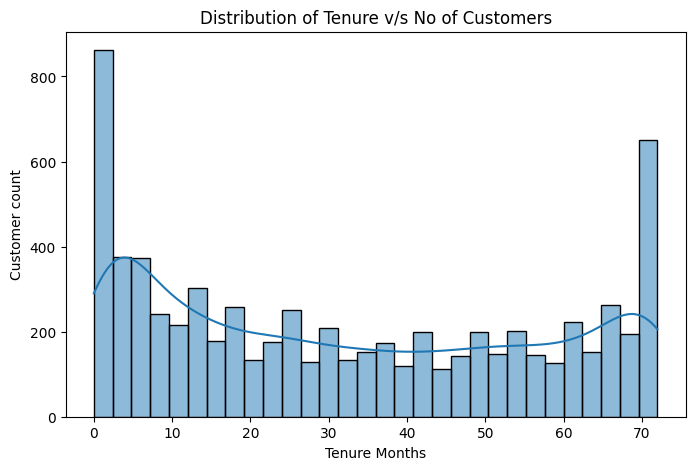

In [9]:
plt.figure( figsize = (8, 5) ) #height and width
sns.histplot(data_frame['Tenure Months'], bins = 30, kde = True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure v/s No of Customers')
plt.show()

In [10]:
data_frame['Tenure Months'].min()

0

In [11]:
data_frame['Tenure Months'].max()

72

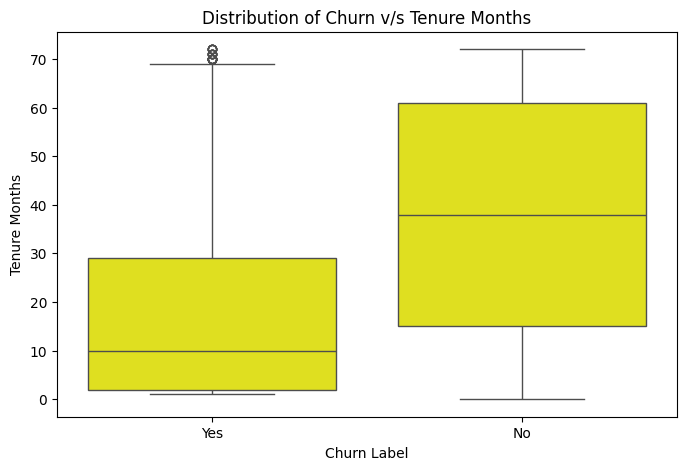

In [12]:
plt.figure( figsize = (8, 5) ) #height and width
sns.boxplot( x = 'Churn Label', y = 'Tenure Months', data = data_frame, color='yellow')
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Distribution of Churn v/s Tenure Months')
plt.show()

In [13]:
#25 percentile is the first line, 50 is second, 75 is third in the box
#50 percent of customers leave the service in first 10months
#50 percent of customers avail the service  in 38 months

In [14]:
data_frame['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

In [15]:
data_frame[data_frame['Churn Label'] == 'targetes']

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason


In [16]:
data_frame['Monthly Charges'].max()

118.75

In [17]:
data_frame['Monthly Charges'].min()

18.25

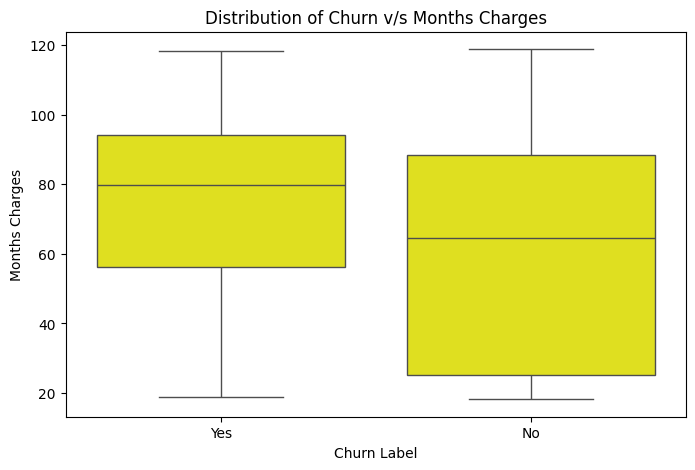

In [18]:
plt.figure( figsize = (8, 5) ) #height and width
sns.boxplot( x = 'Churn Label', y = 'Monthly Charges', data = data_frame, color='yellow')
plt.xlabel('Churn Label')
plt.ylabel('Months Charges')
plt.title('Distribution of Churn v/s Months Charges')
plt.show()

In [19]:
data_frame[data_frame['Churn Label'] == 'targetes']['Monthly Charges'].quantile([0.25, 0.5, 0.75])

0.25   NaN
0.50   NaN
0.75   NaN
Name: Monthly Charges, dtype: float64

In [20]:
data_frame[data_frame['Churn Label'] == 'No']['Monthly Charges'].quantile([0.25, 0.5, 0.7])

0.25    25.100
0.50    64.425
0.70    83.805
Name: Monthly Charges, dtype: float64

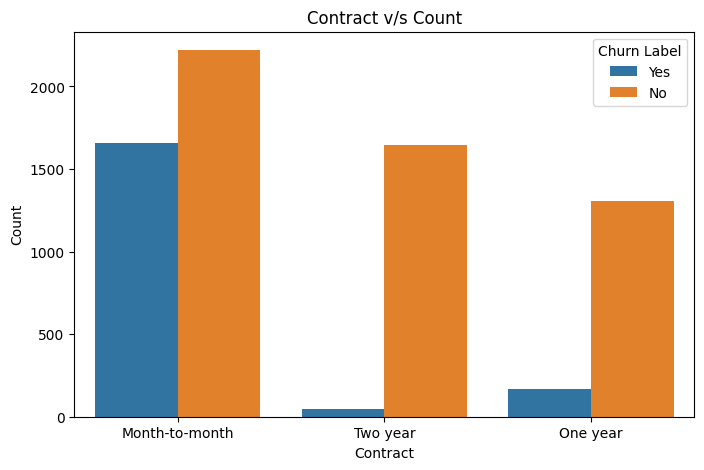

In [21]:
plt.figure( figsize = (8, 5) ) #height and width
sns.countplot( x = 'Contract', hue = 'Churn Label', data = data_frame)
plt.xlabel('Contract')
plt.ylabel('Count')
plt.title('Contract v/s Count')
plt.show()